In [2]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

df=pd.read_csv('../data/reference/results.csv')
df.head()


,city,country,city_slug,n_listings,med_airbnb_price_usd,med_nights,occupancy_pct,annual_revenue_usd,pct_capped,price_sqm_centre,price_sqm_out,price_utilities,roi_centre,roi_outside
0,Chicago,United States,chicago,2935,225.18,138.0,37.8,31075.0,19.1,4094.16,2696.73,193.44,10.98,17.19
1,Edinburgh,United Kingdom,edinburgh,2900,331.86,138.0,37.8,45796.0,27.4,6689.03,4680.85,371.64,9.63,14.19
2,Portland,United States,portland,2009,177.23,144.0,39.5,25521.0,22.4,3896.40,3372.32,290.44,8.86,10.40
3,Columbus,United States,columbus,1112,167.00,132.0,36.2,22044.0,26.2,3440.00,1775.50,222.91,8.77,17.92
4,Minneapolis,United States,twin-cities-msa,1763,197.37,102.0,27.9,20132.0,13.0,3395.59,2174.56,158.11,8.22,13.40


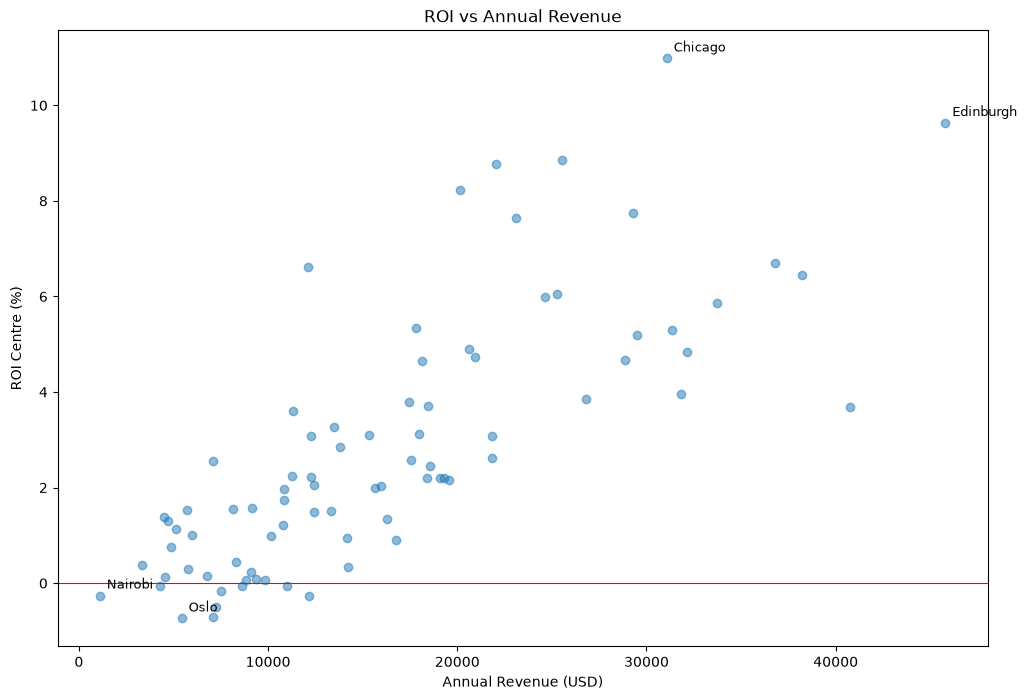

In [13]:
x=df['annual_revenue_usd']
y= df['roi_centre']

fig, ax= plt.subplots(figsize=(12,8))

ax.scatter(x,y, alpha=0.5)
ax.set_xlabel('Annual Revenue (USD)')
ax.set_ylabel('ROI Centre (%)')
ax.set_title ('ROI vs Annual Revenue')
ax.axhline(0, color='r', linewidth=0.8)

picks= pd.concat([df.nlargest(1,'annual_revenue_usd'), df.nlargest(1,'roi_centre'), df.nsmallest(1,'annual_revenue_usd'), df.nsmallest(1,'roi_centre')])

for _, row in picks.iterrows():
     ax.annotate(row["city"], (row["annual_revenue_usd"], row["roi_centre"]),
                xytext=(5, 5), textcoords="offset points", fontsize=9)
plt.savefig('../charts/revenue_vs_roi.png', dpi=150, bbox_inches='tight')
plt.show()
    

In [8]:
df["annual_revenue_usd"].corr(df["roi_centre"])

np.float64(0.7778172999819402)

In [9]:
df['price_sqm_centre'].corr(df['roi_centre'])

np.float64(-0.35445644940638327)

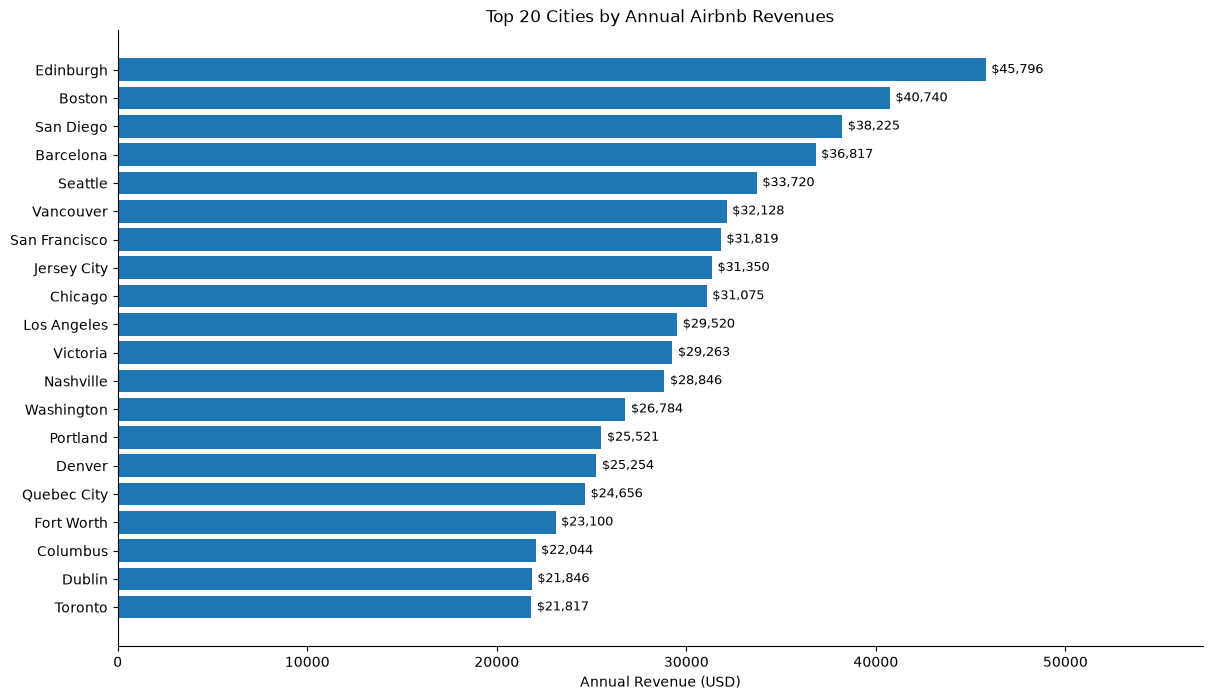

In [14]:

top= df.nlargest(20,'annual_revenue_usd').sort_values('annual_revenue_usd')

x= top['annual_revenue_usd']
y= top['city']
fig, ax= plt.subplots(figsize=(14,8))

ax.barh(y,x)

ax.set_xlabel('Annual Revenue (USD)')
ax.set_title('Top 20 Cities by Annual Airbnb Revenues')
ax.set_xlim(0, top['annual_revenue_usd'].max() * 1.25)
ax.bar_label(ax.containers[0], fmt='${:,.0f}', padding=4, fontsize=9)

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
plt.savefig('../charts/revenue_top20.png', dpi=150, bbox_inches='tight')
plt.show()

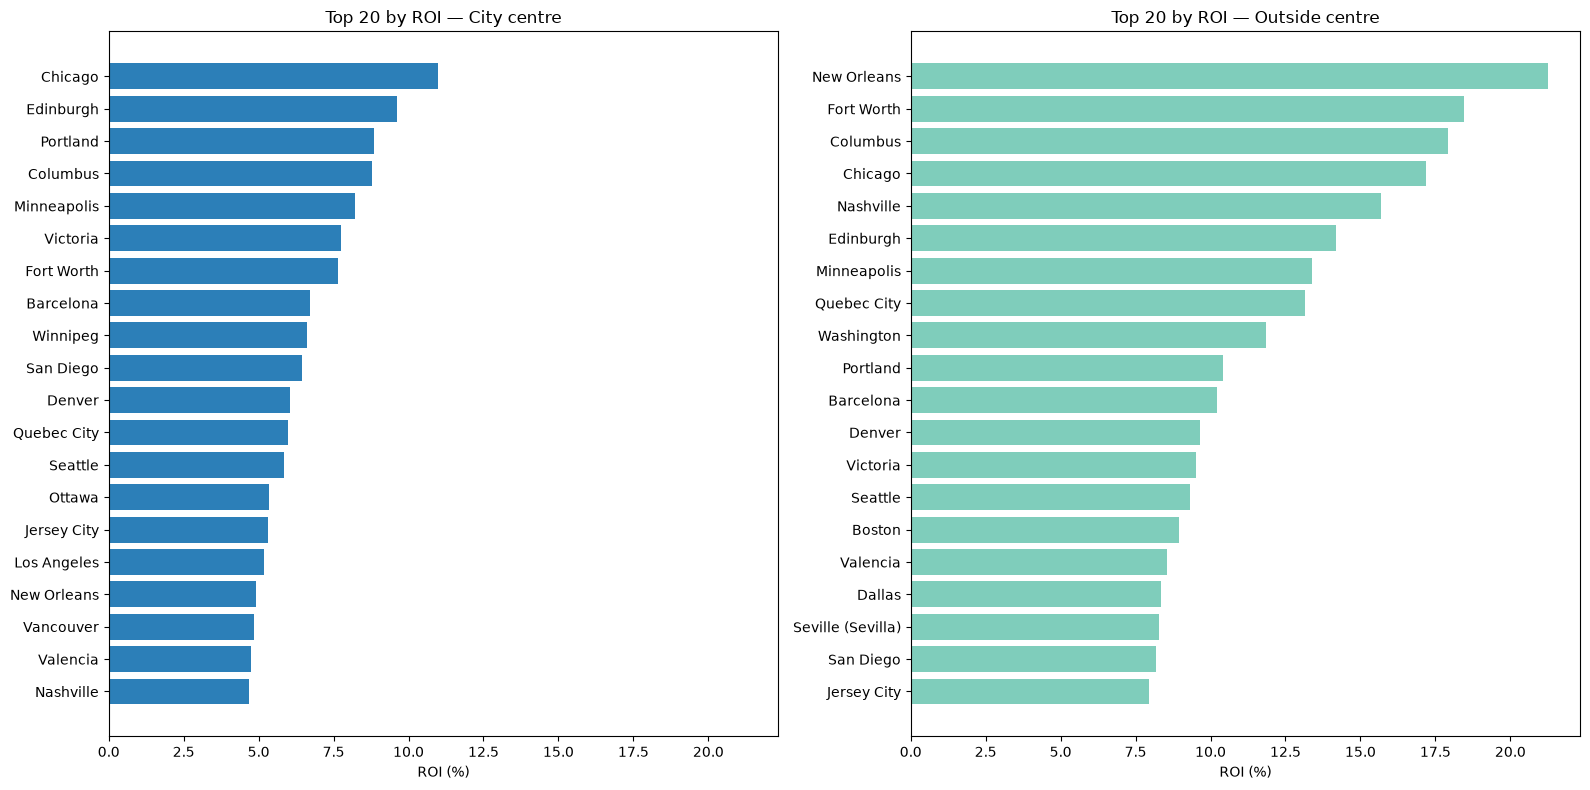

In [29]:
top_centre = df.nlargest(20, 'roi_centre').sort_values('roi_centre')
top_out    = df.nlargest(20, 'roi_outside').sort_values('roi_outside')

fig, ax = plt.subplots(1, 2, figsize=(16, 8))

ax[0].barh(top_centre['city'], top_centre['roi_centre'])
ax[0].set_xlabel('ROI (%)')
ax[0].set_title('Top 20 by ROI — City centre')

ax[1].barh(top_out['city'], top_out['roi_outside'])
ax[1].set_xlabel('ROI (%)')
ax[1].set_title('Top 20 by ROI — Outside centre')

ax[0].barh(top_centre['city'], top_centre['roi_centre'], color='#2c7fb8')
ax[1].barh(top_out['city'], top_out['roi_outside'], color='#7fcdbb')

xmax = max(top_centre['roi_centre'].max(), top_out['roi_outside'].max()) * 1.05
ax[0].set_xlim(0, xmax)
ax[1].set_xlim(0, xmax)

plt.tight_layout()

plt.show()

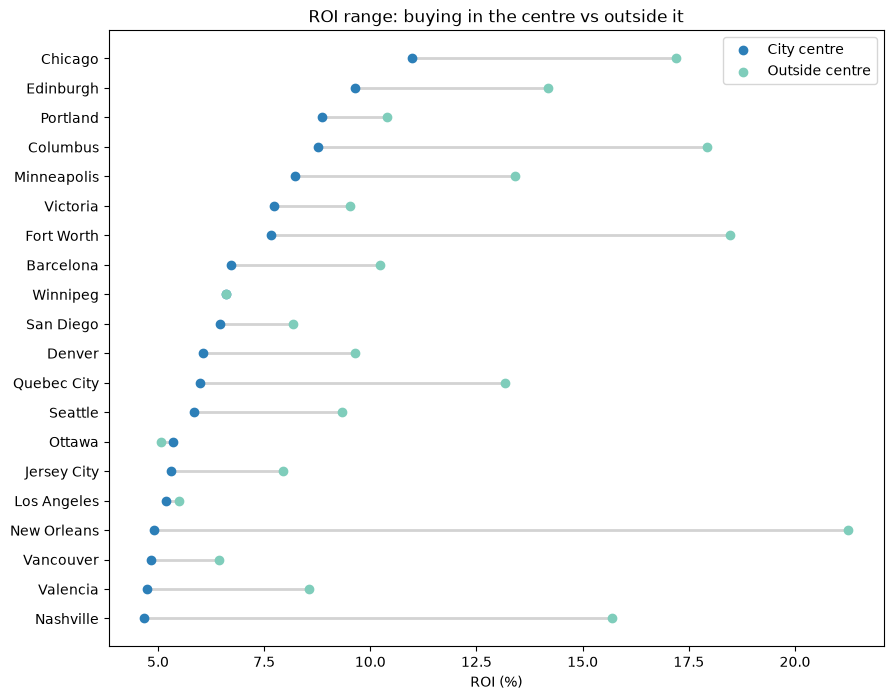

In [30]:
top = df.nlargest(20, 'roi_centre').sort_values('roi_centre')

fig, ax = plt.subplots(figsize=(10, 8))

ax.hlines(y=top['city'], xmin=top['roi_centre'], xmax=top['roi_outside'],
          color='lightgrey', linewidth=2)
ax.scatter(top['roi_centre'], top['city'], color='#2c7fb8', label='City centre', zorder=3)
ax.scatter(top['roi_outside'], top['city'], color='#7fcdbb', label='Outside centre', zorder=3)

ax.set_xlabel('ROI (%)')
ax.set_title('ROI range: buying in the centre vs outside it')
ax.legend()

plt.savefig('../charts/roi_range.png', dpi=150, bbox_inches='tight')
plt.show()

In [3]:
df["spread"] = df["roi_outside"] - df["roi_centre"]
df.nlargest(50, "spread")[["city", "country", "roi_centre", "roi_outside", "spread"]]

,city,country,roi_centre,roi_outside,spread
16,New Orleans,United States,4.90,21.26,16.36
19,Nashville,United States,4.67,15.69,11.02
6,Fort Worth,United States,7.65,18.47,10.82
3,Columbus,United States,8.77,17.92,9.15
22,Washington,United States,3.85,11.84,7.99
11,Quebec City,Canada,5.98,13.16,7.18
0,Chicago,United States,10.98,17.19,6.21
42,Dallas,United States,2.16,8.36,6.20
25,Boston,United States,3.69,8.94,5.25
31,Seville (Sevilla),Spain,3.07,8.27,5.20


In [12]:
df.groupby('country')['spread'].mean().sort_values(ascending=False)

country
United States        4.877619
Mexico               3.970000
Spain                3.672000
Turkey               3.000000
Belgium              2.480000
Italy                2.255000
Ireland              1.950000
Canada               1.894286
Brazil               1.680000
Portugal             1.675000
United Kingdom       1.652500
Japan                1.470000
Hungary              1.300000
Austria              1.290000
South Africa         1.180000
Australia            0.963333
Argentina            0.880000
France               0.836667
Thailand             0.800000
Sweden               0.800000
Taiwan               0.730000
Germany              0.710000
Netherlands          0.686667
Latvia               0.650000
Czech Republic       0.640000
Kenya                0.430000
Greece               0.425000
Colombia             0.400000
Denmark              0.330000
Hong Kong (China)    0.190000
Norway               0.180000
Chile                0.100000
Name: spread, dtype: float64